In [1]:
import pandas as pd
import numpy as np


# ============================================================
# 1. LOAD DATASET
# ============================================================

data = pd.read_csv(
    r"C:\Users\s2\Documents\Federated\kk\dataset\DigitalExposome Dataset.csv"
)

print("Jumlah data :", len(data))
print("Jumlah fitur:", len(data.columns) - 1)

print(data.head())


# %%
# ============================================================
# 2. CEK DATA
# ============================================================

data.info()

print("\nJumlah data Null:")
print(data.isna().sum())

print("\nJumlah data duplicate:")
print(data.duplicated().sum())


# %%
# ============================================================
# 3. CEK OUTLIER
# ============================================================

numeric_cols = data.select_dtypes(
    include="number"
).columns

outlier_counts = {}

for col in numeric_cols:

    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = (
        (data[col] < lower_bound) |
        (data[col] > upper_bound)
    ).sum()

    outlier_counts[col] = outliers


print("\nJumlah outlier setiap kolom:")
print(pd.Series(outlier_counts))


# %%
# ============================================================
# 4. OUTLIER PER BARIS
# ============================================================

outlier_mask = pd.Series(
    False,
    index=data.index
)

for col in numeric_cols:

    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_mask |= (
        (data[col] < lower_bound) |
        (data[col] > upper_bound)
    )


print(
    "\nJumlah baris yang mengandung outlier:",
    outlier_mask.sum()
)


# %%
# ============================================================
# 5. FEATURES DAN LABEL
# ============================================================

X = data.drop(
    columns=["Label"]
)

y = data["Label"]


print("\nShape X:", X.shape)
print("Shape y:", y.shape)

print("\nDistribusi label:")
print(y.value_counts())

Jumlah data : 42436
Jumlah fitur: 11
   IBI        HR  NO2     Noise       NH3      PM10        CO      PM25  \
0  0.0  0.377574  0.0  0.511358  0.003018  0.003091  0.871758  0.000000   
1  0.0  0.196398  0.0  0.490903  0.003018  0.003091  0.876848  0.003091   
2  0.0  0.454163  0.0  0.470449  0.006036  0.006181  0.881939  0.006181   
3  0.0  0.322451  0.0  0.449995  0.009055  0.009272  0.887030  0.009272   
4  0.0  0.237595  0.0  0.429540  0.012073  0.012362  0.892121  0.012362   

   Label       PM1  EDA  BVP  
0      5  0.000000  0.0  0.0  
1      5  0.001854  0.0  0.0  
2      5  0.003709  0.0  0.0  
3      5  0.005563  0.0  0.0  
4      5  0.007417  0.0  0.0  
<class 'pandas.DataFrame'>
RangeIndex: 42436 entries, 0 to 42435
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   IBI     42436 non-null  float64
 1   HR      42436 non-null  float64
 2   NO2     42436 non-null  float64
 3   Noise   42436 non-null  float64
 4   N

In [2]:
# ============================================================
# 6. MEMBUAT DATA FEDERATED
# ============================================================
from dataset import (
    make_federated_splits,
    print_federated_splits,
    print_oversampling_distribution
)

clients = make_federated_splits(
    # -----------------------------------------
    # INPUT DATASET
    # -----------------------------------------
    X=X,
    y=y,

    # -----------------------------------------
    # CLIENT
    # -----------------------------------------
    n_clients=4,

    # -----------------------------------------
    # DISTRIBUSI DATA
    # -----------------------------------------
    mode="non_iid",
    alpha=0.5,

    # -----------------------------------------
    # SPLIT
    # -----------------------------------------
    test_size=0.15,
    val_size=0.15,
    seed=42,

    # -----------------------------------------
    # OVERSAMPLING
    # -----------------------------------------
    oversample_method="smote"
)

In [3]:
# ============================================================
# 7. CEK HASIL PEMBAGIAN CLIENT
# ============================================================

print_federated_splits(
    clients,
    title="Non-IID + SMOTE"
)


# %%
# ============================================================
# 8. CEK DISTRIBUSI SEBELUM / SESUDAH OVERSAMPLING
# ============================================================

print_oversampling_distribution(
    clients,
    title="Distribusi sebelum dan sesudah SMOTE"
)


== Non-IID + SMOTE ==
Client 0: train=8895 [0, 1779, 1779, 1779, 1779, 1779] | val=925 [0, 3, 133, 243, 381, 165] | test=925 [0, 3, 133, 243, 381, 165]
Client 1: train=11355 [0, 2271, 2271, 2271, 2271, 2271] | val=1567 [0, 423, 1, 405, 251, 487] | test=1567 [0, 423, 1, 405, 251, 487]
Client 2: train=40810 [0, 8162, 8162, 8162, 8162, 8162] | val=2684 [0, 27, 802, 75, 30, 1750] | test=2684 [0, 28, 801, 75, 30, 1750]
Client 3: train=21095 [0, 4219, 4219, 4219, 4219, 4219] | val=1191 [0, 905, 16, 13, 235, 22] | test=1191 [0, 905, 16, 13, 235, 22]

== Distribusi sebelum dan sesudah SMOTE ==
Client 0: before=[0, 12, 621, 1134, 1779, 770] → after=[0, 1779, 1779, 1779, 1779, 1779]
Client 1: before=[0, 1971, 8, 1888, 1170, 2271] → after=[0, 2271, 2271, 2271, 2271, 2271]
Client 2: before=[0, 129, 3740, 352, 139, 8162] → after=[0, 8162, 8162, 8162, 8162, 8162]
Client 3: before=[0, 4219, 75, 63, 1097, 102] → after=[0, 4219, 4219, 4219, 4219, 4219]


In [ ]:
from federated import run_federated_learning, compute_num_classes, final_test_evaluation

num_classes = compute_num_classes(y)   # pakai ini, bukan len(set(y))

history = run_federated_learning(
    clients,
    input_dim=X.shape[1],
    num_classes=num_classes,
    num_rounds=10,
    n_clients=4,
)

print(history["metrics_distributed"])
print(history["losses_distributed"])

2026-09-24 14:53:27,318	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
INFO :      Starting Flower ServerApp, config: num_rounds=20, no round_timeout
INFO :      
INFO :      [INIT]
INFO :      Using initial global parameters provided by strategy
INFO :      Evaluating initial global parameters
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)
INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      configure_evaluate: strategy sampled 4 clients (out of 4)
INFO :      aggregate_evaluate: received 4 results and 0 failures
INFO :      
INFO :      [ROUND 2]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)


[Round 1] loss=1.1646 | {'accuracy': 0.5914873566828962, 'recall': 0.6245524417680379, 'f1': 0.4161418357460416, 'precision': 0.43076085903754247}


INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      configure_evaluate: strategy sampled 4 clients (out of 4)
INFO :      aggregate_evaluate: received 4 results and 0 failures
INFO :      
INFO :      [ROUND 3]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)


[Round 2] loss=0.9193 | {'accuracy': 0.6890215171980525, 'recall': 0.7090729964449178, 'f1': 0.4899029011298038, 'precision': 0.48879734990785334}


INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      configure_evaluate: strategy sampled 4 clients (out of 4)
INFO :      aggregate_evaluate: received 4 results and 0 failures
INFO :      
INFO :      [ROUND 4]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)


...

[Round 18] loss=0.8333 | {'accuracy': 0.8101146536830532, 'recall': 0.7964933803053645, 'f1': 0.5872744980793245, 'precision': 0.5708971378511051}


INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      configure_evaluate: strategy sampled 4 clients (out of 4)
INFO :      aggregate_evaluate: received 4 results and 0 failures
INFO :      
INFO :      [ROUND 20]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)


[Round 19] loss=0.8460 | {'accuracy': 0.8065022773676771, 'recall': 0.7923544821143812, 'f1': 0.5888053349356815, 'precision': 0.5711157280857142}


INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      configure_evaluate: strategy sampled 4 clients (out of 4)
INFO :      aggregate_evaluate: received 4 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 20 round(s) in 165.32s
INFO :      	History (loss, distributed):
INFO :      		round 1: 1.164583343575434
INFO :      		round 2: 0.9192989292672015
INFO :      		round 3: 0.8508562533732241
INFO :      		round 4: 0.8351461309848933
INFO :      		round 5: 0.850507793423518
INFO :      		round 6: 0.869161619708698
INFO :      		round 7: 0.8259470025757634
INFO :      		round 8: 0.8119329866405108
INFO :      		round 9: 0.8206359766118283
INFO :      		round 10: 0.8144260854516614
INFO :      		round 11: 0.8284117512057373
INFO :      		round 12: 0.8376073294313507
INFO :      		round 13: 0.8411580879777759
INFO :      		round 14: 0.8492053903982182
INFO :      		round 15: 0.8164315895006723
INFO :      		round 16: 0.841553725982098
INF

[Round 20] loss=0.9274 | {'accuracy': 0.8013193026543113, 'recall': 0.7836618615307138, 'f1': 0.5956364769264614, 'precision': 0.5821721713362823}
[(1, {'accuracy': 0.5914873566828962, 'recall': 0.6245524417680379, 'f1': 0.4161418357460416, 'precision': 0.43076085903754247}), (2, {'accuracy': 0.6890215171980525, 'recall': 0.7090729964449178, 'f1': 0.4899029011298038, 'precision': 0.48879734990785334}), (3, {'accuracy': 0.7303282550651798, 'recall': 0.7379041913279583, 'f1': 0.5205479943328757, 'precision': 0.5145429112916433}), (4, {'accuracy': 0.7477618972828648, 'recall': 0.7472648608382537, 'f1': 0.5359721620533184, 'precision': 0.5280748290265928}), (5, {'accuracy': 0.7560860687922099, 'recall': 0.760329793032091, 'f1': 0.5374813024410123, 'precision': 0.5272874629582042}), (6, {'accuracy': 0.7672373174179362, 'recall': 0.7717230783201965, 'f1': 0.5546140657577416, 'precision': 0.5423539011112823}), (7, {'accuracy': 0.7713208732527093, 'recall': 0.7734428188988962, 'f1': 0.55494050

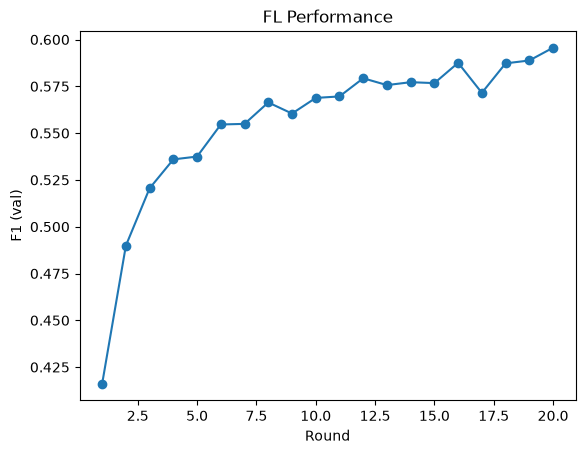

In [5]:
import matplotlib.pyplot as plt

rounds = [r for r, _ in history["metrics_distributed"]]
f1_scores = [m["f1"] for _, m in history["metrics_distributed"]]

plt.plot(rounds, f1_scores, marker="o")
plt.xlabel("Round"); plt.ylabel("F1 (val)"); plt.title("FL Performance")
plt.show()